In [1]:
# Uncomment before running each time Notebook/Environment is started
# !pip install meteostat==1.6.8

In [2]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
from meteostat import Point, Hourly

ModuleNotFoundError: No module named 'meteostat'

In [3]:
FLIGHT_DATA = "Illinois_Carrier_Performance_2026_1.csv"
AIRPORT_META_DATA = "NTAD_Aviation_Facilities.csv"

### Load and clean flight data

In [4]:
`df = pd.read_csv(FLIGHT_DATA, low_memory=False)
df.columns = df.columns.str.strip()
df = df.replace(r"^\s*$", np.nan, regex=True)
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
numeric_cols = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime",
    "Distance", "DistanceGroup", "Cancelled", "Diverted",
    "DepDel15", "DepDelayMinutes", "ArrDel15", "ArrDelayMinutes",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Limit the data to exclude cancelled or diverted flights. 
# Only include rows that have values for DepDel15, CRSDepTime, Origin, Dest, and FlightDate
df = df[df["Origin"] == "ORD"] #Only keep data for O'Hare airport for initial build
df = df[df["Cancelled"]  != 1]
df = df[df["Diverted"]   != 1]
df = df[df["DepDel15"].notna()]
df = df[df["CRSDepTime"].notna()]
df = df[df["Origin"].notna()]
df = df[df["Dest"].notna()]
df = df[df["FlightDate"].notna()]
print(df.shape)

(26119, 120)

### Update dates and times to more usable formats

- Update scheduled departure hour from CRSDepTime to user friendly time \(e\.g\. 1322 = 1:22PM\)

- Calculating total minutes since midnight for continuous time representation

- Update scheduled arrival time from CSArrTime to user friendly time

- Applying cyclical sine/cosine encoding to scheduled departure time so the model understands that 11:59 PM and 12:00 AM are close together, not 1439 minutes apart

- This allows us to calculate AM and PM 

- Building a route string \(e\.g\. 'ATL\_ORD'\) to capture origin\-destination pair as a single feature

- Flagging weekend flights  as a binary feature

- Extracting week of year and day of year to capture seasonal delay patterns

- Binning scheduled departure time into human\-readable periods:
      0\-559   \-\> late\_night
      600\-859 \-\> early\_morning
      900\-1159 \-\> morning
      1200\-1459 \-\> midday
      1500\-1759 \-\> afternoon
      1800\-2059 \-\> evening
      2100\-2359 \-\> night

- Creating sched\_dep\_dt by combining FlightDate \+ sched\_dep\_hour, floored to the hour

In [5]:
# scheduled departure breakdown
df["sched_dep_hour"] = (df["CRSDepTime"] // 100).astype("Int64")
df["sched_dep_minute"] = (df["CRSDepTime"] %  100).astype("Int64")
df["sched_dep_minutes_since_midnight"] = (
    df["sched_dep_hour"] * 60 + df["sched_dep_minute"]
)

# scheduled arrival breakdown
df["sched_arr_hour"] = (df["CRSArrTime"].fillna(0).astype(int) // 100)
df["sched_arr_minute"] = (df["CRSArrTime"].fillna(0).astype(int) %  100)

# cyclical time encoding
df["sched_dep_sin"] = np.sin(
    2 * np.pi * df["sched_dep_minutes_since_midnight"] / 1440
)
df["sched_dep_cos"] = np.cos(
    2 * np.pi * df["sched_dep_minutes_since_midnight"] / 1440
)

# route and date features
df["route"] = df["Origin"].astype(str) + "_" + df["Dest"].astype(str)
df["is_weekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)
df["week_of_year"] = df["FlightDate"].dt.isocalendar().week.astype("Int64")
df["day_of_year"] = df["FlightDate"].dt.dayofyear

# departure time bins
bins = [0, 600, 900, 1200, 1500, 1800, 2100, 2400]
labels = ["late_night", "early_morning", "morning", "midday",
          "afternoon", "evening", "night"]
df["dep_time_bin"] = pd.cut(
    df["CRSDepTime"].astype(float),
    bins=bins, labels=labels, right=False
).astype(str)

# rounded departure datetime — used as the weather join key
df["sched_dep_dt"] = (
    df["FlightDate"]
    + pd.to_timedelta(df["sched_dep_hour"].astype(float), unit="h")
).dt.floor("h")

### Load airport meta data

In [6]:
airports_meta = pd.read_csv(AIRPORT_META_DATA, low_memory=False)
airports_meta.columns    = airports_meta.columns.str.strip()
airports_meta["ARPT_ID"] = airports_meta["ARPT_ID"].str.strip()

meta_cols = [
    "ARPT_ID",
    "CITY",
    "STATE_CODE",
    "SITE_TYPE_CODE",   # A=airport, H=heliport, etc.
    "REGION_CODE",      # FAA region
    "x",                # longitude
    "y",                # latitude
]
airports_meta = airports_meta[meta_cols].drop_duplicates(subset="ARPT_ID")

### Combine airport meta data and flight data on both origin and destination airports

In [7]:
origin_meta = (
    airports_meta
    .add_prefix("origin_meta_")
    .rename(columns={"origin_meta_ARPT_ID": "Origin"})
)
df = df.merge(origin_meta, on="Origin", how="left")

dest_meta = (
    airports_meta
    .add_prefix("dest_meta_")
    .rename(columns={"dest_meta_ARPT_ID": "Dest"})
)
df = df.merge(dest_meta, on="Dest", how="left")

### Build Meteostat Point coords from the airport latitude and longitude data 

In [8]:
AIRPORT_COORDS = {}
for _, row in airports_meta.dropna(subset=["x", "y"]).iterrows():
    AIRPORT_COORDS[row["ARPT_ID"]] = Point(
        lat=row["y"],
        lon=row["x"],
    )

active_airports = (
    set(df["Origin"].dropna().unique()) |
    set(df["Dest"].dropna().unique())
)
AIRPORT_COORDS_FILTERED = {
    k: v for k, v in AIRPORT_COORDS.items() if k in active_airports
}

### Get Meteostat hourly weather for all active airports 

In [9]:
WEATHER_START = df["FlightDate"].min().to_pydatetime()
WEATHER_END   = df["FlightDate"].max().to_pydatetime()
weather_frames = []
for iata, point in AIRPORT_COORDS_FILTERED.items():
    print(f"  {iata}...", end=" ", flush=True)
    try:
        w = Hourly(point, WEATHER_START, WEATHER_END).fetch().reset_index()
        if w.empty:
            print("no data")
            continue
        w["airport"] = iata
        weather_frames.append(w)
        print(f"{len(w):,} rows")
    except Exception as e:
        print(f"failed ({e})")

if not weather_frames:
    raise RuntimeError(
        "No weather data fetched. Check airport coordinates and date range."
    )

weather_df = pd.concat(weather_frames, ignore_index=True)
weather_df["time"] = pd.to_datetime(weather_df["time"])

  BHM... 721 rows
  HSV... 721 rows
  PHX... 721 rows
  TUS... 721 rows
  XNA... 721 rows
  LIT... 721 rows
  FAT... 721 rows
  LAX... 721 rows
  ONT... 721 rows
  PSP... 721 rows
  SMF... 721 rows
  SAN... 721 rows
  SFO... 721 rows
  SJC... 721 rows
  SNA... 721 rows
  ASE... 721 rows
  COS... 721 rows
  DEN... 721 rows
  EGE... 721 rows
  GUC... 721 rows
  HDN... 721 rows
  MTJ... 721 rows
  BDL... 721 rows
  DCA... 721 rows
  IAD... 721 rows
  FLL... 721 rows
  RSW... 721 rows
  JAX... 721 rows
  EYW... 721 rows
  MIA... 721 rows
  MCO... 721 rows
  ECP... 721 rows
  PNS... 721 rows
  SRQ... 721 rows
  TPA... 721 rows
  VPS... 721 rows
  PBI... 721 rows
  ATL... 721 rows
  SAV... 721 rows
  BOI... 721 rows
  SUN... 721 rows
  BMI... 721 rows
  CMI... 721 rows
  ORD... 721 rows
  DEC... 721 rows
  MLI... 721 rows
  PIA... 721 rows
  SPI... 721 rows
  EVV... 721 rows
  FWA... 721 rows
  IND... 721 rows
  LAF... 721 rows
  SBN... 721 rows
  CID... 721 rows
  DSM... 721 rows
  FOD... 7

### Combine origin and destination weather to flights 

In [10]:
WEATHER_COLS = [
    "temp", "dwpt", "rhum", "prcp",
    "snow", "wspd", "wpgt", "pres", "coco"
]
# Origin weather 
origin_wx = (
    weather_df[weather_df["airport"].isin(df["Origin"].dropna().unique())]
    [["time", "airport"] + WEATHER_COLS]
    .rename(columns={
        "time":    "sched_dep_dt",
        "airport": "Origin",
        **{c: f"origin_{c}" for c in WEATHER_COLS},
    })
)
df = df.merge(origin_wx, on=["sched_dep_dt", "Origin"], how="left")

# Destination weather 
dest_wx = (
    weather_df[weather_df["airport"].isin(df["Dest"].dropna().unique())]
    [["time", "airport"] + WEATHER_COLS]
    .rename(columns={
        "time":    "sched_dep_dt",
        "airport": "Dest",
        **{c: f"dest_{c}" for c in WEATHER_COLS},
    })
)
df = df.merge(dest_wx, on=["sched_dep_dt", "Dest"], how="left")
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,origin_coco,dest_temp,dest_dwpt,dest_rhum,dest_prcp,dest_snow,dest_wspd,dest_wpgt,dest_pres,dest_coco
0,2026,1,1,8,4,2026-01-08,UA,UA_CODESHARE,19977,UA,...,3.0,3.0,-1.0,75.0,0.0,NaN,5.5,NaN,1022.0,1.0
1,2026,1,1,8,4,2026-01-08,UA,UA_CODESHARE,19977,UA,...,7.0,7.0,4.0,81.0,0.0,NaN,7.0,NaN,1004.0,3.0
2,2026,1,1,8,4,2026-01-08,UA,UA_CODESHARE,19977,UA,...,3.0,11.0,11.0,100.0,0.0,NaN,5.5,NaN,1019.0,4.0
3,2026,1,1,8,4,2026-01-08,UA,UA_CODESHARE,19977,UA,...,3.0,3.0,2.6,97.0,0.0,NaN,9.0,NaN,1020.0,5.0
4,2026,1,1,8,4,2026-01-08,UA,UA_CODESHARE,19977,UA,...,3.0,13.0,10.0,82.0,0.0,NaN,25.9,NaN,1006.0,3.0


### Drop leakage columns

In [11]:
leakage_cols = [
    "DepTime", "DepDelay", "DepDelayMinutes", "DepartureDelayGroups",
    "TaxiOut", "WheelsOff", "WheelsOn", "TaxiIn",
    "ArrTime", "ArrDelay", "ArrDelayMinutes", "ArrDel15",
    "ArrivalDelayGroups", "ActualElapsedTime", "AirTime",
    "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay",
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

### Explore delay metrics by hour and with a correlation map of numeric features 

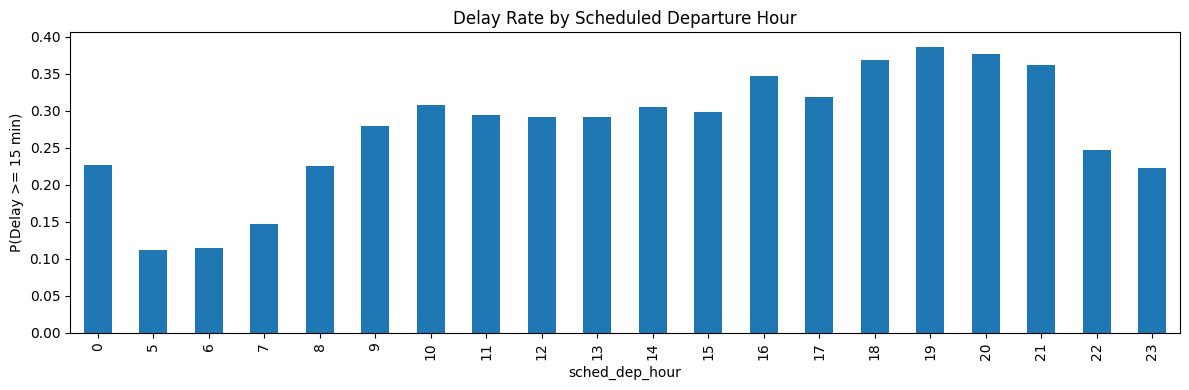

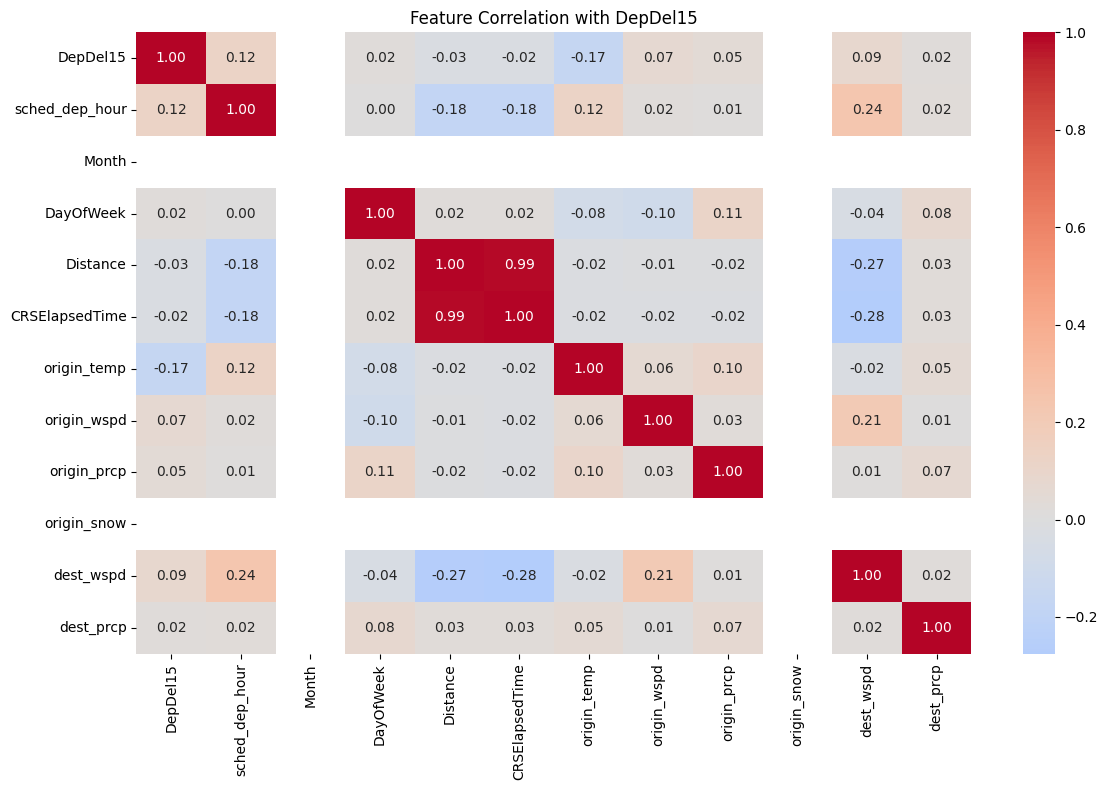

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate delay rates by carrier
carrier_delay = (
    df.groupby("Marketing_Airline_Network")["DepDel15"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "delay_rate", "count": "flights"})
    .sort_values("delay_rate", ascending=False)
)

# Delay rates by hour of the day 
hour_delay = df.groupby("sched_dep_hour")["DepDel15"].mean()
hour_delay.plot(kind="bar", figsize=(12, 4), title="Delay Rate by Scheduled Departure Hour")
plt.ylabel("P(Delay >= 15 min)")
plt.tight_layout()
plt.show()

# Calculate delay rate by FAA region 
region_delay = df.groupby("origin_meta_REGION_CODE")["DepDel15"].mean().sort_values(ascending=False)


# Correlation heatmap for numeric features 
num_cols_for_corr = [
    "DepDel15", "sched_dep_hour", "Month", "DayOfWeek", "Distance",
    "CRSElapsedTime", "origin_temp", "origin_wspd", "origin_prcp",
    "origin_snow", "dest_wspd", "dest_prcp", "calc_distance_km"
]
corr = df[[c for c in num_cols_for_corr if c in df.columns]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation with DepDel15")
plt.tight_layout()
plt.show()

In [14]:
df.to_csv("cleaned_flight_data.csv", index=False)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=834a7fd8-5d92-452c-800f-6398af925425' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>